<a href="https://colab.research.google.com/github/Devashish-23/Devashish-23/blob/main/kaggle_EX_MACHINA_competition_iiitA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
LOADING DATASET

In [3]:
train = pd.read_csv('/content/train_n (1) (2).csv')
test = pd.read_csv('/content/test_n (1) (3).csv')
sample = pd.read_csv('/content/sample_submission (2).csv')

print(train.shape)
print(test.shape)

train.head()

(4000, 57)
(1000, 56)


,id,Unnamed: 0,acc,acc_id,loc,t,dt,y0,y1,ts,...,tp,ord,txt,tag,note,eff,cat,img,cap,y
0,2929,2929,1,1983.1.14,NaN,Beach Scene at Trouville,1863,1863.0,1863.0,1851 to 1875,...,NaN,NaN,NaN,NaN,NaN,NaN,painted surface|Beach|Trouville|French Paintin...,https://api.nga.gov/iiif/85f2142e-1b34-4e75-a0...,A oil on wood artwork titled 'Beach Scene at T...,4
1,3224,3224,1,1951.16.5,NaN,Playing Cards,15th century,1400.0,1499.0,1300 to 1400,...,NaN,NaN,NaN,NaN,NaN,NaN,Lombard,https://api.nga.gov/iiif/717a802a-4449-4cf6-8b...,A print artwork titled 'Playing Cards' by Unkn...,5
2,3351,3351,1,2008.115.2454,NaN,Agriculture,1939,1939.0,1939.0,1926 to 1950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://api.nga.gov/iiif/5b8cada2-0d67-45bb-96...,A print artwork titled 'Agriculture' by Unknow...,5
3,1736,1736,1,1958.9.7,NaN,"Burning of Old South Church, Bath, Maine",c. 1854,1854.0,1854.0,1851 to 1875,...,previous_attribution,1.0,American 19th Century,American 19th Century,Attribution at time of gift,NaN,"American|Bath, ME|Old South Church|American Na...",https://api.nga.gov/iiif/c8befcd8-4237-4652-ba...,A oil on canvas artwork titled 'Burning of Old...,2
4,1813,1813,1,1963.10.52,13181.0,Le gourmet,1901,1901.0,1901.0,1901 to 1925,...,NaN,NaN,NaN,NaN,NaN,NaN,Eating|Twentieth and Twenty-first Century Pain...,https://api.nga.gov/iiif/e19a2b28-639c-4d6a-84...,A oil on canvas artwork titled 'Le gourmet' by...,2


Understanding the data

In [4]:
train.info()
train.describe()

# Check missing values
train.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           4000 non-null   int64  
 1   Unnamed: 0                   4000 non-null   int64  
 2   acc                          4000 non-null   int64  
 3   acc_id                       4000 non-null   object 
 4   loc                          667 non-null    float64
 5   t                            4000 non-null   object 
 6   dt                           3746 non-null   object 
 7   y0                           3999 non-null   float64
 8   y1                           3999 non-null   float64
 9   ts                           3999 non-null   object 
 10  dim                          3768 non-null   object 
 11  inscription                  2333 non-null   object 
 12  markings                     166 non-null    object 
 13  attributioninverte

,0
volume,3994
eff,3903
subclassification,3893
customprinturl,3850
watermarks,3839
markings,3834
parentid,3690
portfolio,3626
note,3618
series,3615


basic EDA (EXPLANATORY DATA ANALYSIS)

In [7]:
# Target distribution
sns.countplot(x='artistic_medium', data=train)
plt.xticks(rotation=45)
plt.show()

ValueError: Could not interpret value `artistic_medium` for `x`. An entry with this name does not appear in `data`.

In [36]:
train.isnull().sum().sort_values(ascending=False)

,0
volume,3994
eff,3903
subclassification,3893
customprinturl,3850
watermarks,3839
parentid,3690
portfolio,3626
series,3615
tag,3572
tp,3497


In [37]:
train_clean = train.dropna()

In [38]:
train.isnull().sum().sum()

np.int64(52087)

In [40]:
train.isnull().sum().sum()

np.int64(52087)

In [41]:
total_missing = train.isnull().sum().sum()
print("Total missing values in dataset:", total_missing)

Total missing values in dataset: 52087


In [8]:
print(train.columns)

Index(['id', 'Unnamed: 0', 'acc', 'acc_id', 'loc', 't', 'dt', 'y0', 'y1', 'ts',
       'dim', 'inscription', 'markings', 'attributioninverted', 'attribution',
       'provenancetext', 'creditline', 'classification', 'subclassification',
       'visualbrowserclassification', 'parentid', 'isvirtual',
       'departmentabbr', 'portfolio', 'series', 'volume', 'watermarks',
       'lastdetectedmodification', 'wikidataid', 'customprinturl', 'label',
       'uuid', 'iiifurl', 'iiifthumburl', 'viewtype', 'sequence', 'width',
       'height', 'maxpixels', 'created', 'modified', 'depictstmsobjectid',
       'assistivetext', 'element', 'dimensiontype', 'dimension', 'unitname',
       'tp', 'ord', 'txt', 'tag', 'note', 'eff', 'cat', 'img', 'cap', 'y'],
      dtype='object')


In [9]:
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

print(train.columns)

Index(['id', 'Unnamed: 0', 'acc', 'acc_id', 'loc', 't', 'dt', 'y0', 'y1', 'ts',
       'dim', 'inscription', 'markings', 'attributioninverted', 'attribution',
       'provenancetext', 'creditline', 'classification', 'subclassification',
       'visualbrowserclassification', 'parentid', 'isvirtual',
       'departmentabbr', 'portfolio', 'series', 'volume', 'watermarks',
       'lastdetectedmodification', 'wikidataid', 'customprinturl', 'label',
       'uuid', 'iiifurl', 'iiifthumburl', 'viewtype', 'sequence', 'width',
       'height', 'maxpixels', 'created', 'modified', 'depictstmsobjectid',
       'assistivetext', 'element', 'dimensiontype', 'dimension', 'unitname',
       'tp', 'ord', 'txt', 'tag', 'note', 'eff', 'cat', 'img', 'cap', 'y'],
      dtype='object')


In [10]:
train.head()

,id,Unnamed: 0,acc,acc_id,loc,t,dt,y0,y1,ts,...,tp,ord,txt,tag,note,eff,cat,img,cap,y
0,2929,2929,1,1983.1.14,NaN,Beach Scene at Trouville,1863,1863.0,1863.0,1851 to 1875,...,NaN,NaN,NaN,NaN,NaN,NaN,painted surface|Beach|Trouville|French Paintin...,https://api.nga.gov/iiif/85f2142e-1b34-4e75-a0...,A oil on wood artwork titled 'Beach Scene at T...,4
1,3224,3224,1,1951.16.5,NaN,Playing Cards,15th century,1400.0,1499.0,1300 to 1400,...,NaN,NaN,NaN,NaN,NaN,NaN,Lombard,https://api.nga.gov/iiif/717a802a-4449-4cf6-8b...,A print artwork titled 'Playing Cards' by Unkn...,5
2,3351,3351,1,2008.115.2454,NaN,Agriculture,1939,1939.0,1939.0,1926 to 1950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://api.nga.gov/iiif/5b8cada2-0d67-45bb-96...,A print artwork titled 'Agriculture' by Unknow...,5
3,1736,1736,1,1958.9.7,NaN,"Burning of Old South Church, Bath, Maine",c. 1854,1854.0,1854.0,1851 to 1875,...,previous_attribution,1.0,American 19th Century,American 19th Century,Attribution at time of gift,NaN,"American|Bath, ME|Old South Church|American Na...",https://api.nga.gov/iiif/c8befcd8-4237-4652-ba...,A oil on canvas artwork titled 'Burning of Old...,2
4,1813,1813,1,1963.10.52,13181.0,Le gourmet,1901,1901.0,1901.0,1901 to 1925,...,NaN,NaN,NaN,NaN,NaN,NaN,Eating|Twentieth and Twenty-first Century Pain...,https://api.nga.gov/iiif/e19a2b28-639c-4d6a-84...,A oil on canvas artwork titled 'Le gourmet' by...,2


In [11]:
sns.countplot(x='medium', data=train)
plt.xticks(rotation=45)
plt.show()

ValueError: Could not interpret value `medium` for `x`. An entry with this name does not appear in `data`.

In [12]:
print(train.columns)

Index(['id', 'Unnamed: 0', 'acc', 'acc_id', 'loc', 't', 'dt', 'y0', 'y1', 'ts',
       'dim', 'inscription', 'markings', 'attributioninverted', 'attribution',
       'provenancetext', 'creditline', 'classification', 'subclassification',
       'visualbrowserclassification', 'parentid', 'isvirtual',
       'departmentabbr', 'portfolio', 'series', 'volume', 'watermarks',
       'lastdetectedmodification', 'wikidataid', 'customprinturl', 'label',
       'uuid', 'iiifurl', 'iiifthumburl', 'viewtype', 'sequence', 'width',
       'height', 'maxpixels', 'created', 'modified', 'depictstmsobjectid',
       'assistivetext', 'element', 'dimensiontype', 'dimension', 'unitname',
       'tp', 'ord', 'txt', 'tag', 'note', 'eff', 'cat', 'img', 'cap', 'y'],
      dtype='object')


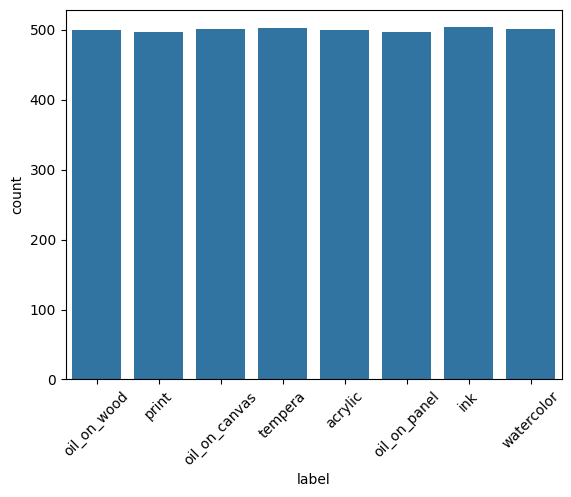

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=train)
plt.xticks(rotation=45)
plt.show()

In [14]:
train.columns = train.columns.str.strip().str.lower()
test.columns = test.columns.str.strip().str.lower()

In [15]:
text_cols = ['txt', 'cap', 'note', 'inscription', 'markings',
             'provenancetext', 'creditline']

# Fill missing
for col in text_cols:
    train[col] = train[col].fillna('')
    test[col] = test[col].fillna('')

In [16]:
train['combined_text'] = train[text_cols].agg(' '.join, axis=1)
test['combined_text'] = test[text_cols].agg(' '.join, axis=1)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=8000, stop_words='english')

X_text_train = tfidf.fit_transform(train['combined_text'])
X_text_test = tfidf.transform(test['combined_text'])

In [18]:
num_cols = ['width', 'height', 'maxpixels']

train_num = train[num_cols].fillna(0)
test_num = test[num_cols].fillna(0)

In [19]:
from scipy.sparse import hstack

X_train = hstack([X_text_train, train_num])
X_test = hstack([X_text_test, test_num])

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(train['label'])

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [22]:
preds = model.predict(X_test)
preds = le.inverse_transform(preds)

In [23]:
sample['label'] = preds
sample.to_csv('submission.csv', index=False)

In [25]:
sample = sample[['id', 'label']]  # keep only required columns
sample.to_csv('submission.csv', index=False)

In [26]:
sample.head()

,id,label
0,4503,acrylic
1,4874,watercolor
2,2342,oil_on_panel
3,4142,oil_on_wood
4,4786,tempera


In [27]:
# Keep only required columns (VERY IMPORTANT)
final_submission = sample[['id', 'label']]

# Save with your desired name
final_submission.to_csv('final_submission.csv', index=False)

# Preview
final_submission.head()

,id,label
0,4503,acrylic
1,4874,watercolor
2,2342,oil_on_panel
3,4142,oil_on_wood
4,4786,tempera


In [28]:
from google.colab import files
files.download('final_submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y, test_size=0.2, random_state=42)

model.fit(X_tr, y_tr)
y_pred = model.predict(X_val)

KeyboardInterrupt: 

In [29]:
import pandas as pd

final = pd.read_csv('final_submission.csv')
final.head()

,id,label
0,4503,acrylic
1,4874,watercolor
2,2342,oil_on_panel
3,4142,oil_on_wood
4,4786,tempera


In [31]:
label_counts = final['label'].value_counts()
print(label_counts)

label
oil_on_wood      159
ink              153
watercolor       147
print            140
acrylic          137
tempera          123
oil_on_panel      97
oil_on_canvas     44
Name: count, dtype: int64


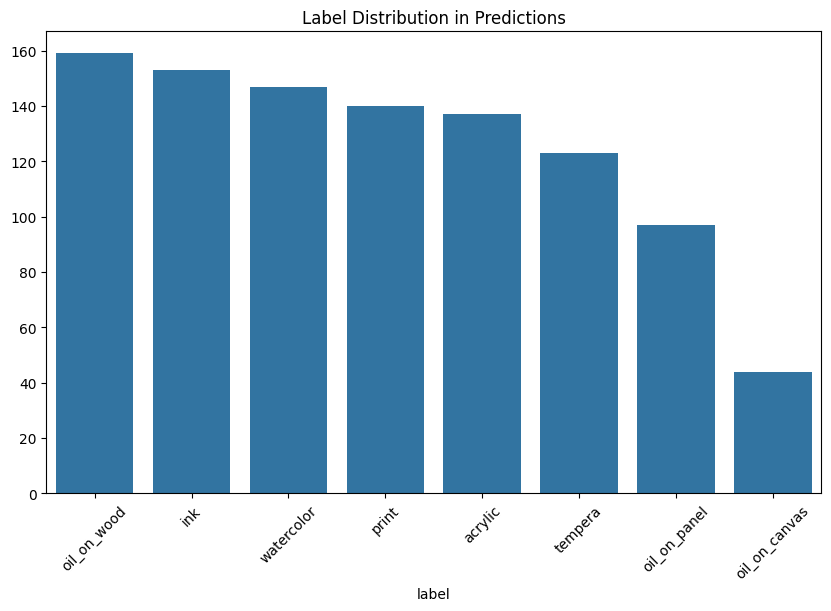

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45)
plt.title("Label Distribution in Predictions")
plt.show()

In [33]:
final['word_count'] = final['label'].apply(lambda x: len(x.split('_')))

final['word_count'].value_counts()

,count
word_count,
1,700
3,300


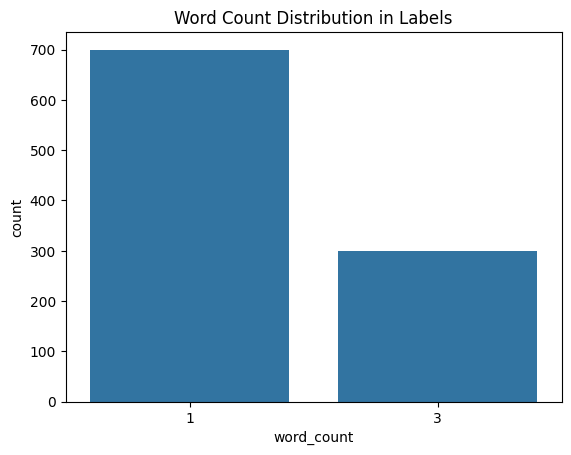

In [34]:
sns.countplot(x='word_count', data=final)
plt.title("Word Count Distribution in Labels")
plt.show()

In [35]:
from collections import Counter

words = []

for label in final['label']:
    words.extend(label.split('_'))

word_freq = Counter(words)

print(word_freq.most_common(10))

[('oil', 300), ('on', 300), ('wood', 159), ('ink', 153), ('watercolor', 147), ('print', 140), ('acrylic', 137), ('tempera', 123), ('panel', 97), ('canvas', 44)]
